# Evaluating a Kalman filter on measured TESLA data

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import numpy as np
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import util_data
import ex_detuning

### KIND dataset loading

For convenience, we load a KIND-specific dataset, where measured data is already split into stationary and transient variants.

In [2]:
parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/kalman',
        '--file_name', 'detuning_meas',
        '--data_nsample', '144',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
    ]
)

dataset = ex_detuning.dataset_filtered(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample)
)
_, _, data_loader = dataset.load(data_type='nom')


### Kalman filter design

In [3]:
dt = 0.001

param = {
    'f'  :   np.array([100., 40., 10.]),
    'q'  :   np.array([1000., 400., 100.]),
    'k'  :   np.array([-1.0, 1.0, -0.1]),
    'dt' :   dt,
    'kalman_q' : 1.0,
    'kalman_r' : 0.1,
}
ft = ex_detuning.filter_detuning(param)
c = ex_detuning.make_mm_c_array(len(param['f']))

### Kalman filter evaluation

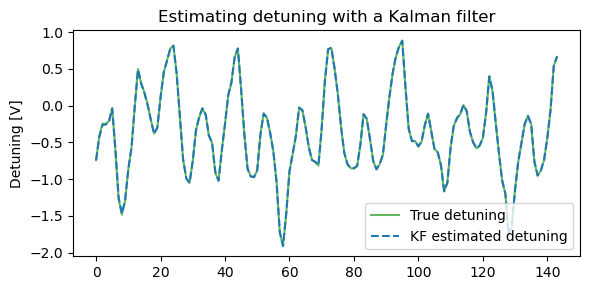

In [4]:
grad = 9.5 * 0.1615
u = np.array([[np.square(grad)]])

detuning_est = []
jdata = 21

for back, fore in data_loader:
    data = torch.cat([back, fore], dim=1)
    data = data[jdata]

    for j in range(data.shape[0]):
        # --! measurement
        z = data[j, 0]

        # --! kalman filter step
        ft.predict(u=u)
        ft.update(np.array([z]))

        # --! save estimated detuning
        ft_est = np.squeeze(c @ ft.x)
        detuning_est.append(ft_est)

    detuning_est = np.array(detuning_est).reshape(-1, 1)

    plt.figure(figsize=(6, 3))

    plt.plot(data[:, 0], label='True detuning', color='tab:green', alpha=0.75, linestyle='solid')
    plt.plot(detuning_est[:, 0], label='KF estimated detuning', color='tab:blue', alpha=1., linestyle='dashed')
    plt.ylabel('Detuning [V]')
    plt.legend()
    plt.title('Estimating detuning with a Kalman filter')
    plt.tight_layout()

    plt.show()

    datasaved = False

    if datasaved:
        step = np.arange(data.shape[0]).reshape(-1, 1)
        savedata = np.expand_dims(
            np.concatenate(
                [step[:, [0]], data[:, [0]], detuning_est[:, [0]]], axis=1), 0)
        util_data.write_datafile('../../savedata/kalman/detuning_kalman_stat_perfect_q_1_r_01', savedata, delim=' ')
    break